In [32]:

from __future__ import annotations
import numpy as np
import pyvista as pv
import matplotlib.pyplot as plt
import math
from tqdm import tqdm
import scipy as scp


%matplotlib inline


In [33]:
from twistedGraphite import TwistGraphite_Bzero,TwistGraphite_LL

## Finding the Fermi surface for B = 0

I use the pyvista package which create smooth and fluid interactive graphs. It is a quite poweful package. To install I did:

    pip install pyvista(only for python)
    pip install trame
    pip install 'jupyterlab' 'pyvista[all]'(to use in jupyter)

Then the rest of this file should work.

To find the Fermi surface I did took the Graphite cell that we used for to calculate the path along the bands. I took a rectangular surface around all the points in the hexagonal cell to get not lose any information.The surface is,
$$
k_x \in [-0.0189,0.0189]\\
k_y \in [-0.0165,0.0165]\\
k_z \in [0,0.5]
$$

Then calculate the energy in this volume and check where it crosses zero,i.e. where it crosses the bands cross the Fermi energy $E_F = 0$.

The fermi surface is found at angle 2.1 deg.

In [3]:
model = TwistGraphite_Bzero(theta=2.1)
model.init_mesh(ecut=1)

We do a test to find which bands cross the Fermi energy 

In [4]:
e,kz = model.energy_kz(401,kx = 0.0,ky = 0.0,giveE=True)

401it [00:00, 2499.75it/s]


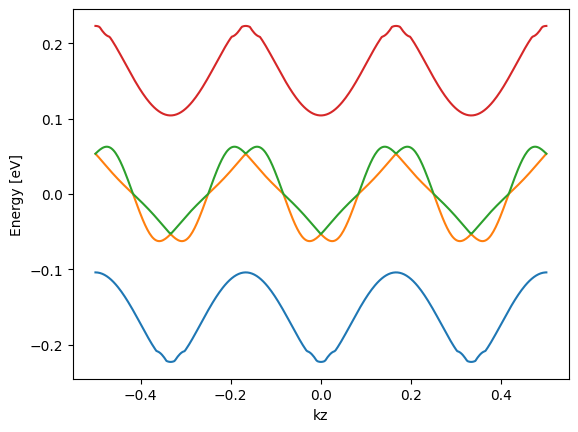

In [7]:
plt.figure()
plt.plot(kz,e[:,17])
plt.plot(kz,e[:,18])
plt.plot(kz,e[:,19])
plt.plot(kz,e[:,20])
plt.xlabel('kz')
plt.ylabel('Energy [eV]')
plt.show()

At 2,1 deg the only bands that cross zero are the bands 18 and 19 so I will calculate the Fermi surface for both of them. $k_z$ is symmetric around 0 so I just take $k_z \in [0,0.5]$ 

In [34]:
kxpts = np.linspace(-0.0189,0.0189,60)
kypts = np.linspace(-0.0165,0.0165,60)
kzpts = np.linspace(0.0,0.5,60)

Collect all the energy values in the volume.

In [35]:
band18energy = np.zeros([len(kxpts),len(kypts),len(kzpts)],dtype=float)
band19energy = np.zeros([len(kxpts),len(kypts),len(kzpts)],dtype=float)

for i,kx in tqdm(enumerate(kxpts)):
    for j,ky in enumerate(kypts):
        for k,kz in enumerate(kzpts):
            h=model.hamiltonian(k = [kx,ky],kz=kz)
            e = np.linalg.eigvalsh(h)
            band18energy[i,j,k] = e[18]
            band19energy[i,j,k] = e[19]

60it [00:42,  1.40it/s]


We can now plot using pyvista. The result can be exported in html sucht that you can give to someone and open in it on browser, could be useful.

In [36]:
x_min = kxpts[0]
y_min = kypts[0]
z_min = kzpts[0]

print(abs(kxpts[1]-kxpts[0])  , abs(kypts[1]-kypts[0]) , abs(kzpts[1]-kzpts[0]) )

grid = pv.ImageData(
    dimensions =  band18energy.shape ,
   spacing=(abs(kxpts[1]-kxpts[0])  , abs(kypts[1]-kypts[0]) ,abs(kzpts[1]-kzpts[0]) ), 
    origin=(x_min, y_min, z_min)
)

grid2 = grid.copy()

grid.point_data["band18"] = band18energy.flatten(order="F")
grid2.point_data["band19"] = band19energy.flatten(order="F")

mesh = grid.contour([0.0], method='marching_cubes')  # look at zero energy iso-surface
mesh2 = grid2.contour([0.0], method='marching_cubes')

plotter = pv.Plotter()
plotter.add_mesh(mesh, color='red')
plotter.add_mesh(mesh2, color='blue')
plotter.camera_position = 'yz'
plotter.show()

#plotter.save_graphic("fermi-18-19.eps") 

0.0006406779661016944 0.0005593220338983053 0.00847457627118644


Widget(value='<iframe src="http://localhost:55610/index.html?ui=P_0x31527ecc0_7&reconnect=auto" class="pyvista…

So as one can see the Fermi surfaces touch at one point, shown above, (kx,ky) = (0,0) i.e at Gamma point.

## Butterfly for B not zero

I modify the function 'pqlist' into a more appropriate function qplist since our flux is q/p

In [22]:
def gen_qplist(max_p,min_flux =0,max_flux = 1):
    """
    Generate a alist of q,p between min_flux and max_flux with the flux defined as q/p
    Don't put a to big value of p since the then the matrix will be huge
    So max_p is max denominator
    """
    plist = np.array([])
    qlist = np.array([])
    for p in range(1, max_p + 1):
        for q in range(int(max(np.ceil(p * min_flux), 1)), int(np.floor(p * max_flux)) + 1):
            if np.gcd(q, p) == 1:
                plist = np.append(plist, p)
                qlist = np.append(qlist, q)
    qplist = qlist / plist
    s_ind = np.argsort(qplist)
    plist = plist[s_ind]
    qlist = qlist[s_ind]
    qplist = qplist[s_ind]
    return plist, qlist, qplist




I do the butterfly also for a twist of 2.1 to follow up on the B = 0 part.

In [24]:
model2 = TwistGraphite_LL(theta = 2.1)

In [28]:
max_l = 40
kz = 0
ee = []

min_flux = 0.01
max_flux = 5
max_p = 11

plist, qlist, qplist = gen_qplist(max_p, min_flux = min_flux,max_flux=max_flux)

In [29]:
for i in tqdm(range(len(qlist))):
    p = int(plist[i])
    q = int(qlist[i])
    _,h = model2.hamiltonian(p = p,q = q, kz = kz ,max_l = max_l)
    ei = np.linalg.eigvalsh(h)
    ee.append(ei)

100%|██████████| 210/210 [2:27:53<00:00, 42.25s/it]   


210it [00:00, 5610.79it/s]


Text(0, 0.5, 'Energy [meV]')

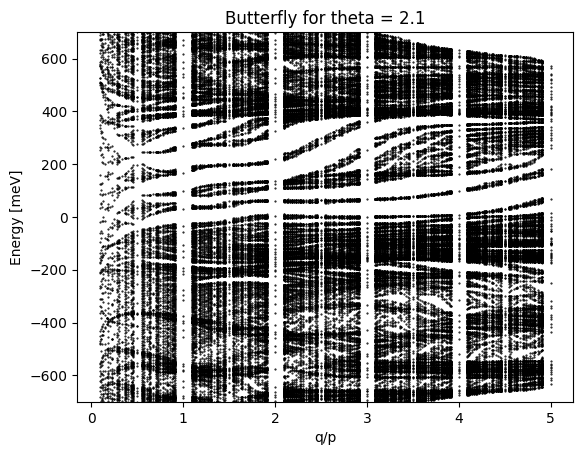

In [31]:
plt.figure
for i,ei in tqdm(enumerate(ee)):
    plt.plot(qplist[i]*np.ones_like(ei),ei,'.k',markersize = 1)
plt.ylim(np.array([-1,1])*700)
#plt.xlim([0,6])
plt.title('Butterfly for theta = 2.1')
plt.xlabel('q/p')
plt.ylabel('Energy [meV]')